In [1]:
%pip install numpy pandas matplotlib scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv"
df=pd.read_csv(url)
pd.set_option("display.max_columns",None)


In [3]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.describe(include='O')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [10]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

In [11]:
df['gender']=df['gender'].map({'Female':1,'Male':0})

In [12]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18816\1570346737.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [13]:
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [14]:
df.drop(columns='customerID',inplace=True)

In [15]:
df['PaperlessBilling']=df['PaperlessBilling'].map({ ' Yes':1, "No":0})


In [16]:
df['StreamingMovies']=df['StreamingMovies'].map({'Yes':1,'No':0,'No internet service':-1})

In [17]:
df.columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [26]:
numerical_cols=['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges']
for i in numerical_cols:
         if df[i].dtype=="object":
          df[i]=pd.factorize(df[i])[0]

In [27]:
numerical_cols=[f for f in numerical_cols if f in df.columns]

In [28]:
df.dropna(inplace=True)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,0,0,0,0,34,0,0,0,0,0,0,0,0,0,0,0.0,0,56.95,1889.50,0
3,0,0,0,0,45,1,1,0,0,0,0,1,0,0,0,0.0,1,42.30,1840.75,0
7,1,0,0,0,10,1,1,0,0,0,1,0,0,0,1,0.0,0,29.75,301.90,0
9,0,0,0,1,62,0,0,0,0,1,1,0,0,0,0,0.0,1,56.15,3487.95,0
11,0,0,0,0,16,0,0,1,1,2,2,2,1,-1,2,0.0,2,18.95,326.80,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7019,1,0,0,0,39,0,0,1,1,2,2,2,1,-1,2,0.0,0,20.15,826.00,0
7027,0,0,0,0,13,0,0,0,2,1,1,1,2,1,1,0.0,0,73.35,931.55,0
7028,1,0,1,0,68,0,0,0,2,1,1,1,2,0,2,0.0,1,64.10,4326.25,0
7031,0,1,1,0,55,0,2,0,0,1,1,0,0,0,0,0.0,2,60.00,3316.10,0


In [29]:
from sklearn.model_selection import train_test_split
X = df[numerical_cols]
y = df['Churn']

#stratify=y
X_train_1, X_test, y_train_1, y_test = train_test_split(X,y,
                                                    test_size=0.20,
                                                    stratify=y)

In [30]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train_1)
X_test=scaler.transform(X_test)
print("Max value in X_train:", np.max(X_train))

Max value in X_train: 3.3421700140024115


In [31]:
x_train,x_val,y_train,y_val=train_test_split(X_train_1,y_train_1,test_size=0.2,random_state=42)

In [32]:
get_ipython().system('pip install Optuna')

  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)

   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ---------------------------------------- 4/4 [Optuna]



In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import optuna

In [34]:
from sklearn.feature_selection import RFE

In [36]:

def obj(k):
  n=k.suggest_int('n_estimators',100,500)
  max_depth=k.suggest_int("max_depth",5,50)
  model=RandomForestClassifier(n_estimators=n, max_depth=max_depth)
  rfe=RFE(estimator=model,n_features_to_select=10)
  rfe.fit(X_train_1,y_train_1)
  return rfe.score(x_val,y_val)
study=optuna.create_study(direction="maximize")
study.optimize(obj,n_trials=10)


[I 2026-06-29 22:08:51,540] A new study created in memory with name: no-name-dbd02297-a76e-410f-910b-cec464cb5506
[I 2026-06-29 22:09:04,097] Trial 0 finished with value: 0.9956521739130435 and parameters: {'n_estimators': 427, 'max_depth': 24}. Best is trial 0 with value: 0.9956521739130435.
[I 2026-06-29 22:09:07,612] Trial 1 finished with value: 0.9934782608695653 and parameters: {'n_estimators': 133, 'max_depth': 26}. Best is trial 0 with value: 0.9956521739130435.
[I 2026-06-29 22:09:13,115] Trial 2 finished with value: 0.9934782608695653 and parameters: {'n_estimators': 204, 'max_depth': 45}. Best is trial 0 with value: 0.9956521739130435.
[I 2026-06-29 22:09:16,058] Trial 3 finished with value: 0.9434782608695652 and parameters: {'n_estimators': 113, 'max_depth': 10}. Best is trial 0 with value: 0.9956521739130435.
[I 2026-06-29 22:09:20,238] Trial 4 finished with value: 0.9956521739130435 and parameters: {'n_estimators': 140, 'max_depth': 39}. Best is trial 0 with value: 0.9956

In [37]:
best_n_estimators = study.best_params['n_estimators']
best_max_depth = study.best_params['max_depth']

best_model = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_max_depth)
rfe = RFE(estimator=best_model, n_features_to_select=10)
rfe.fit(X_train_1, y_train_1)

rfe.support_

array([ True, False, False, False,  True, False, False,  True,  True,
        True, False,  True, False, False,  True, False,  True,  True,
        True])

In [38]:
list(zip(numerical_cols,rfe.support_))
selected_features=[feature for feature, selected in zip(numerical_cols,rfe.support_) if selected]
print(selected_features)

['gender', 'tenure', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [39]:
import pickle
with open('rfe.pickle',"wb") as f:
  pickle.dump(rfe,f)

In [40]:
%pip install tensorflow 
import tensorflow as tf
from tensorflow.keras import layers,models


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 26.0 which is incompatible.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.9 MB 3.4 MB/s eta 0:00:02
   ---------- ----

In [ ]:
def create_ann_model():
  model=(models.Sequential[
      layers.Dense(64,activation='relu',input_shape=(10,)),
      layers.Dense(32,activation='relu'),
      layers.Dense(16,activation='relu'),
      layers.Dense(8,activation='relu'),
      layers.Dense(1,activation='sigmoid')
  ])
  return model

In [43]:
ann_model=create_ann_model()
ann_model.summary()

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
ann_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [50]:
X_train_rfe = rfe.transform(X_train_1)
history=ann_model.fit(X_train_rfe,y_train_1,epochs=32,batch_size=32,validation_split=0.25)

Epoch 1/32
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8055 - loss: 1.4769 - val_accuracy: 0.8522 - val_loss: 0.5448
Epoch 2/32
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8084 - loss: 0.9372 - val_accuracy: 0.8626 - val_loss: 0.3810
Epoch 3/32
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8240 - loss: 0.4844 - val_accuracy: 0.8626 - val_loss: 0.5487
Epoch 4/32
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8043 - loss: 0.9064 - val_accuracy: 0.8661 - val_loss: 0.3921
Epoch 5/32
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8328 - loss: 0.4546 - val_accuracy: 0.6087 - val_loss: 0.6210
Epoch 6/32
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8188 - loss: 0.4824 - val_accuracy: 0.8713 - val_loss: 0.3606
Epoch 7/32
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8328 - loss: 0.4203 - val_accuracy: 0.5374 - val_loss: 0.7950
Epoch 8/32
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8124 - loss: 0.5540 - val_accuracy: 0.8696 - val_loss:

In [56]:
X_test_rfe=rfe.transform(X_test)
predictions=ann_model.predict(X_test_rfe)
print(predictions.min())

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
0.103232935


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RFE was fitted with feature names
  warnings.warn(


In [57]:
y_true = y_test
y_pred = (predictions > 0.25).astype(int)
cm = tf.math.confusion_matrix(labels=y_true, predictions=y_pred)
print(cm)

tf.Tensor(
[[257 224]
 [ 18  76]], shape=(2, 2), dtype=int32)


In [71]:
loss,accuracy=ann_model.evaluate(X_test_rfe,y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8365 - loss: 0.4267 


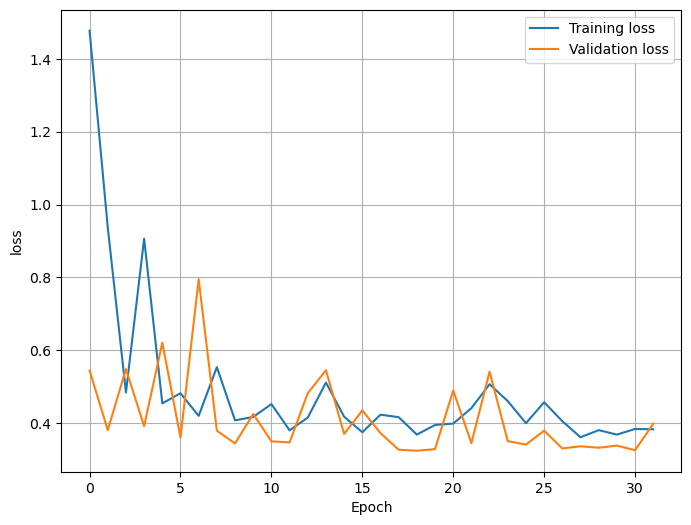

In [64]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.legend()

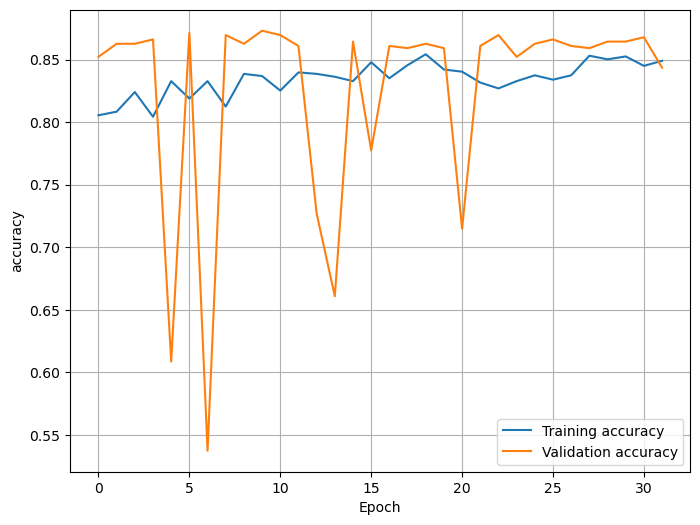

In [65]:
plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'],label='Training accuracy')
plt.plot(history.history['val_accuracy'],label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.grid()
plt.legend()



In [ ]:
#Let me add another ann model but one that is optimized using optuna.

Dropout is a regularization technique where neurons in a neural network are randomly "switched off" (ignored) during training. This forces the network to learn robust, generalizable features instead of relying on specific neurons, which helps prevent overfitting. [1, 2, 3]  
How It Works 

• Random Deactivation: At each training step, neurons and their connections are temporarily removed from the network with a probability of p. The parameter p is known as the dropout rate (e.g., p=0.5 means dropping 50% of the nodes). 
• Scaling: Because fewer neurons are active, the overall output volume decreases. To keep the expected output values consistent, the remaining active neurons are multiplied by 1/(1-p) (known as inverted dropout). 
• Testing/Inference: Dropout is used only during the training phase. During evaluation or testing, the entire network is used, but the output weights are scaled down by the dropout factor to reflect the full network capacity.

Why is Dropout Used? 

• Prevents Co-adaptation: It stops neurons from relying too heavily on their neighboring neurons to fix mistakes, which encourages the network to learn true independent features. 
• Ensemble Learning: It acts as an efficient way to train and combine thousands of smaller, slightly different network architectures. At test time, using the full network approximates averaging the predictions of these smaller models. 

How to Implement 
Most deep learning frameworks provide built-in layers that automatically handle both the random dropping and scaling during training and pass data without interference during testing. 
tf.keras.layers.Dropout(rate=0.5)------How to use in tensorflow?



In [ ]:
def obj(k):
    n_layers=k.suggest_int('n_layers',2,8)
    model=models.Sequential()
    #Adding first_layer
    neurons=k.suggest_int('neuron_0',16,256)
    model.add[
      layers.Dense(neurons,activation='relu',input_shape=(10,))]
    #building inner layers
    for i in range(n_layers):
        neurons1=k.suggest_int(f'neurons_{i+1}',16,256)
        dropout=k.suggest_float(f'dropout_rate_{i+1}',0.2,0.5)
        model.add[
      layers.Dense(neurons1,activation='relu')]

    #Adding output_layer 
    model.add[
      layers.Dense(1,activation='sigmoid')]
    model.add[layers.Dropout(dropout)]

    
        

    